In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler,PolynomialFeatures

In [90]:
df = pd.read_csv("insurance.csv")

In [91]:
print("\nCOLUMN NAMES:\n", df.columns)
print("\nDATA TYPES:\n", df.dtypes)
print("\nAVERAGE VALUES:\n", df.mean(numeric_only=True))
print("\nUNIQUE VALUES:\n")
for col in df.columns:
    print(col, ":", df[col].unique())


COLUMN NAMES:
 Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

DATA TYPES:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

AVERAGE VALUES:
 age            39.207025
bmi            30.663397
children        1.094918
charges     13270.422265
dtype: float64

UNIQUE VALUES:

age : [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
sex : ['female' 'male']
bmi : [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31

Check Missing, Duplicates values

In [92]:
print("\nMISSING VALUES:\n", df.isnull().sum())
print("\nDUPLICATES:", df.duplicated().sum())


MISSING VALUES:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

DUPLICATES: 1


Remove Duplicates

In [93]:
df = df.drop_duplicates()

Visualize Outliers

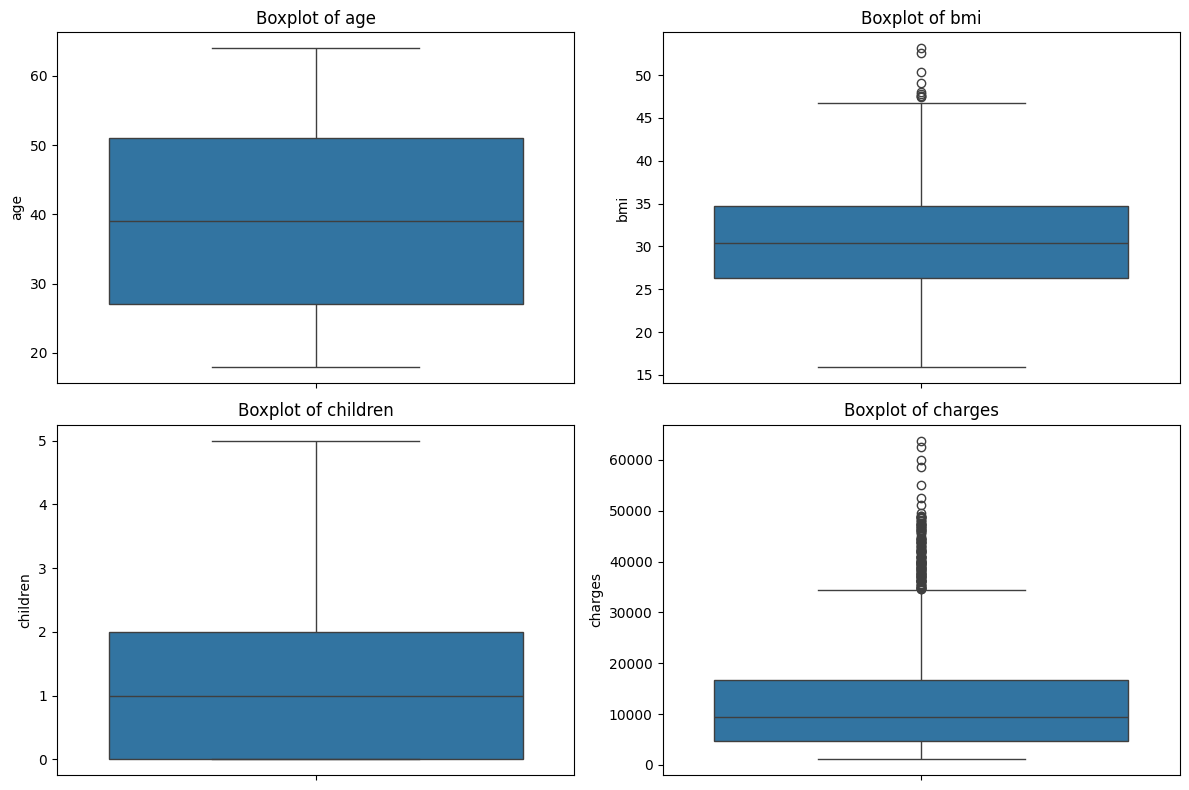

In [94]:

numeric_cols = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)            
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel("")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


Visualization

C:\Users\Pros\AppData\Local\Temp\ipykernel_42848\1319113370.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'])


<Axes: xlabel='charges', ylabel='Density'>

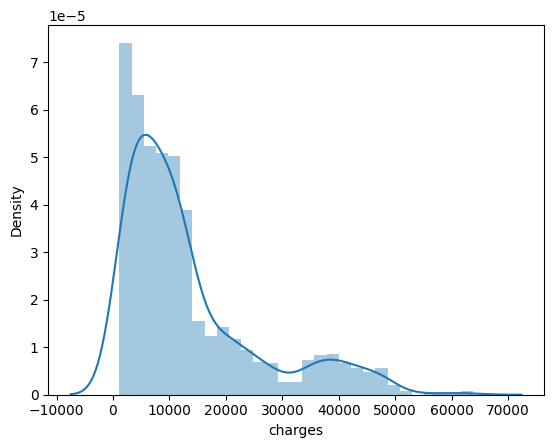

In [95]:
sns.distplot(df['charges'])

<Axes: xlabel='smoker', ylabel='count'>

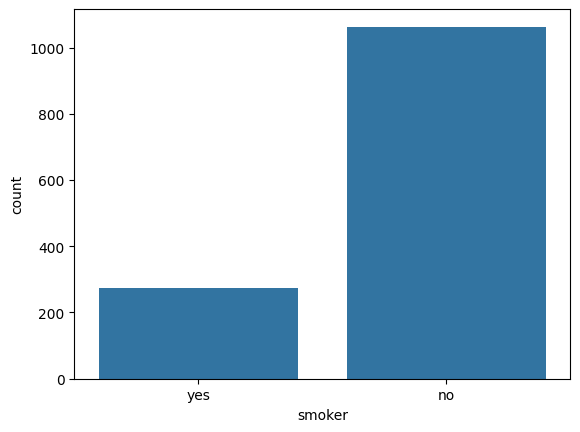

In [96]:
sns.countplot(x= 'smoker' , data = df)

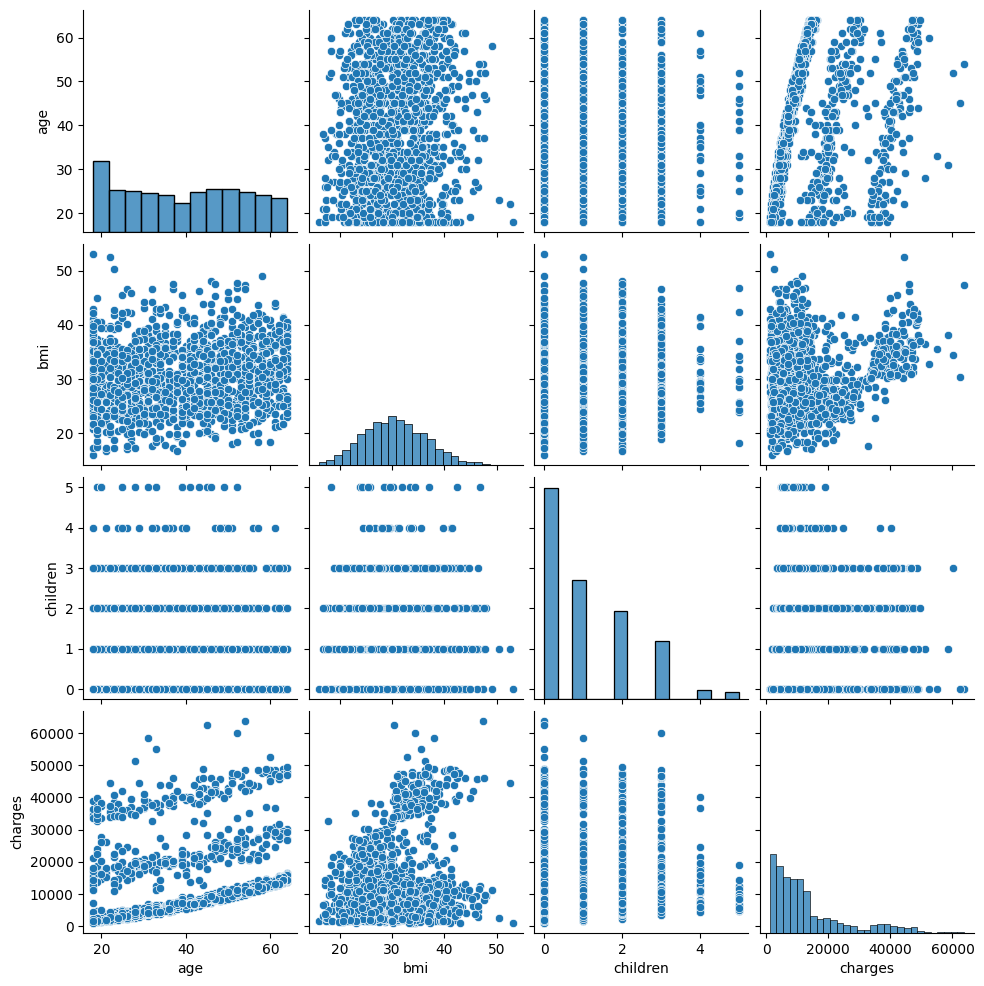

In [97]:
sns.pairplot(df)

<Axes: xlabel='region', ylabel='charges'>

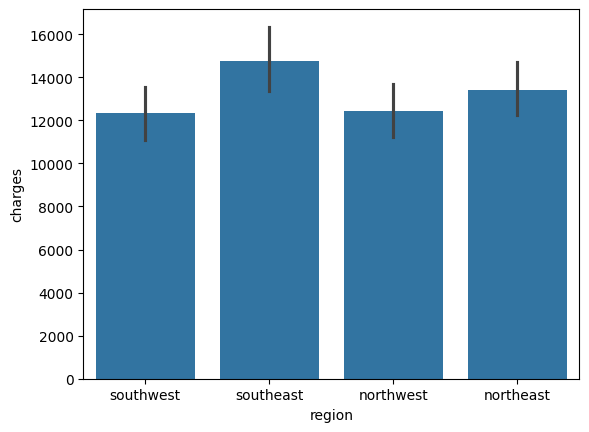

In [98]:
sns.barplot(x= 'region', y = 'charges',data = df)

In [99]:
categorical_cols = ['sex','smoker','region']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough'
)

correlation heatmap

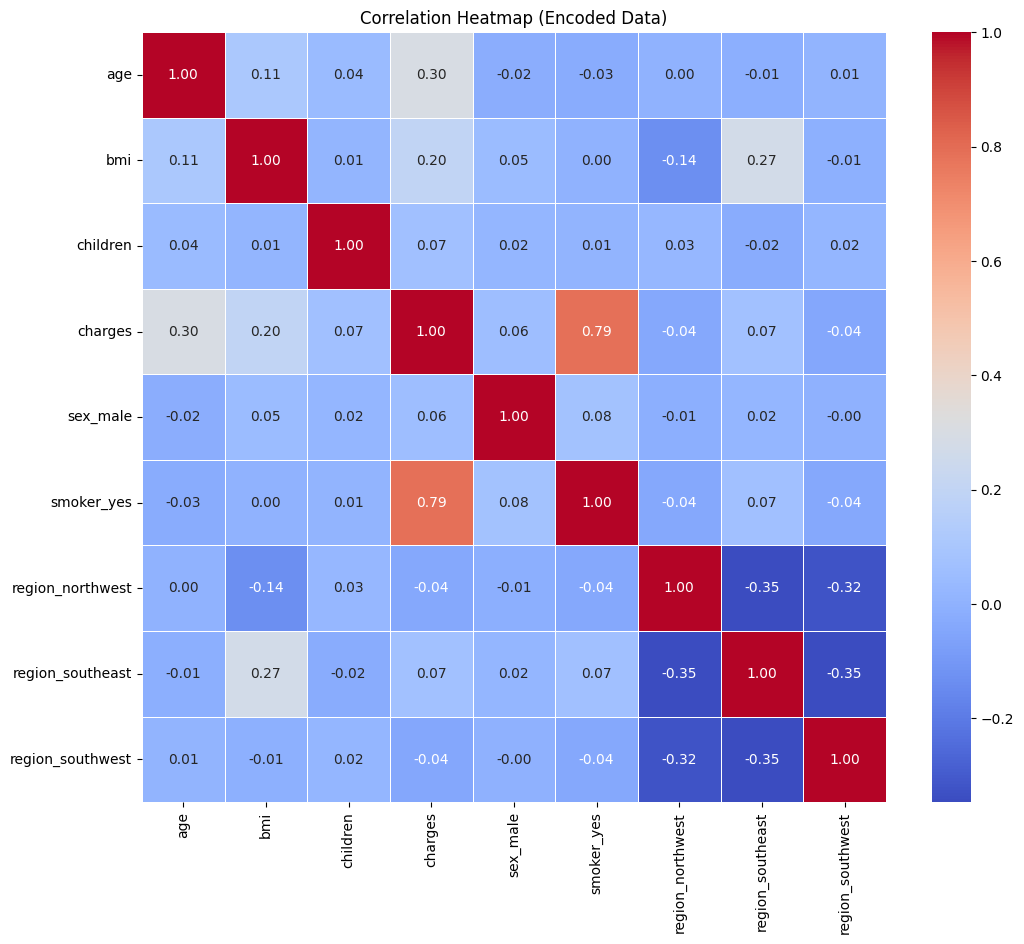

In [100]:
df_encoded = pd.get_dummies(df, drop_first=True)
corr_matrix = df_encoded.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Encoded Data)")
plt.show()


Split Data

In [101]:
X = df.drop('charges', axis=1)
y = df['charges']

X_preprocessed = preprocessor.fit_transform(X)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_preprocessed)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

Model Training

In [102]:
# Simple Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

#Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)


Evaluation

In [103]:
# Calculate MSE
lr_mse = mean_squared_error(y_test, lr_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
dt_mse = mean_squared_error(y_test, dt_pred)

print("\n--- MODEL ERRORS (MSE) ---")
print("Linear Regression:", lr_mse)
print("Ridge:", ridge_mse)
print("Lasso:", lasso_mse)
print("Decision Tree:", dt_mse)

# Calculate R²
lr_r2 = r2_score(y_test, lr_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
lasso_r2 = r2_score(y_test, lasso_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("\n--- R2 SCORE ---")
print("Linear Regression:", lr_r2)
print("Ridge:", ridge_r2)
print("Lasso:", lasso_r2)
print("Decision Tree:", dt_r2)




--- MODEL ERRORS (MSE) ---
Linear Regression: 35478020.67523552
Ridge: 35513023.469242565
Lasso: 35478094.2149537
Decision Tree: 34226460.43808437

--- R2 SCORE ---
Linear Regression: 0.8069287081198017
Ridge: 0.8067382230101553
Lasso: 0.8069283079168557
Decision Tree: 0.8137396955213996


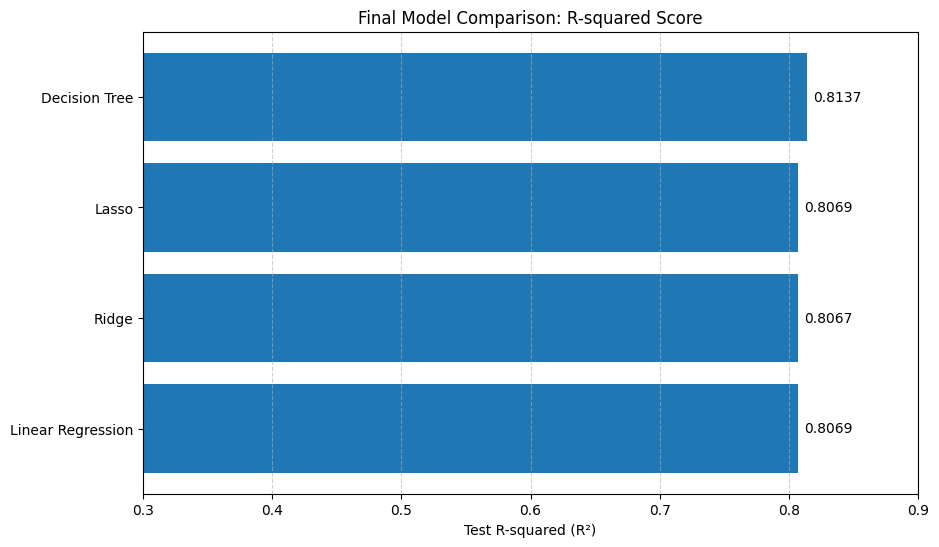

In [104]:
import matplotlib.pyplot as plt


models = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "Decision Tree"
]

r2_scores = [
    lr_r2,
    ridge_r2,
    lasso_r2,
    dt_r2
]

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(models, r2_scores)


for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f"{width:.4f}", va='center')


plt.xlabel("Test R-squared (R²)")
plt.title("Final Model Comparison: R-squared Score")


plt.xlim(0.3, 0.9)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()


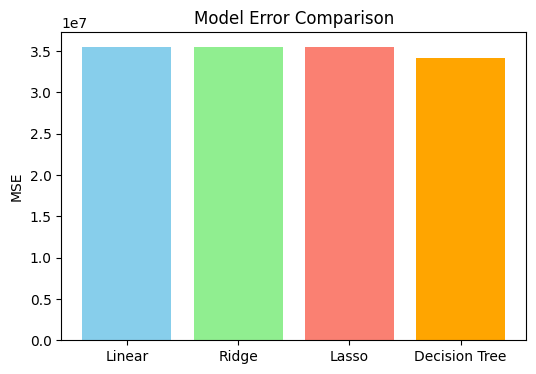

In [105]:
models = ['Linear', 'Ridge', 'Lasso', 'Decision Tree']
mse_values = [lr_mse, ridge_mse, lasso_mse, dt_mse]

plt.figure(figsize=(6,4))
plt.bar(models, mse_values, color=['skyblue','lightgreen','salmon','orange'])
plt.ylabel("MSE")
plt.title("Model Error Comparison")
plt.show()


Actual vs Predicted Plot

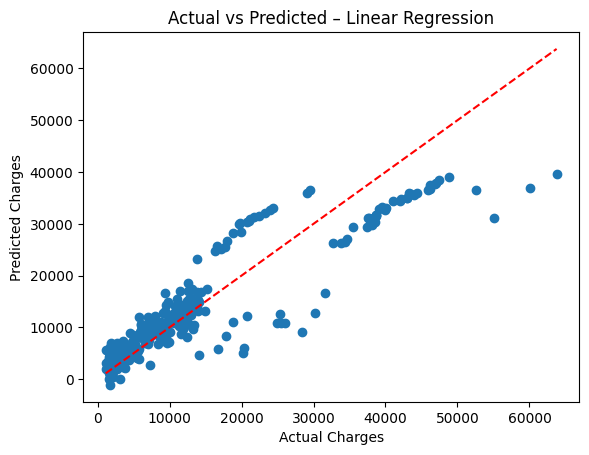

In [106]:
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted – Linear Regression")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

shap

In [107]:
original_feature_names = [
    'age',
    'bmi',
    'children',
    'sex_male',
    'smoker_yes',
    'region_northwest',
    'region_southeast',
    'region_southwest'
]


In [108]:
X_train_df = pd.DataFrame(X_train, columns=original_feature_names)
X_test_df = pd.DataFrame(X_test, columns=original_feature_names)


In [109]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_df)
X_test_poly = poly.transform(X_test_df)


In [110]:
feature_names = poly.get_feature_names_out(original_feature_names)


In [ ]:
from sklearn.linear_model import LinearRegression

# Train model 
model = LinearRegression()
model.fit(X_train_poly, y_train)

# SHAP
import shap
explainer = shap.Explainer(model, X_train_poly)
shap_values = explainer(X_test_poly)

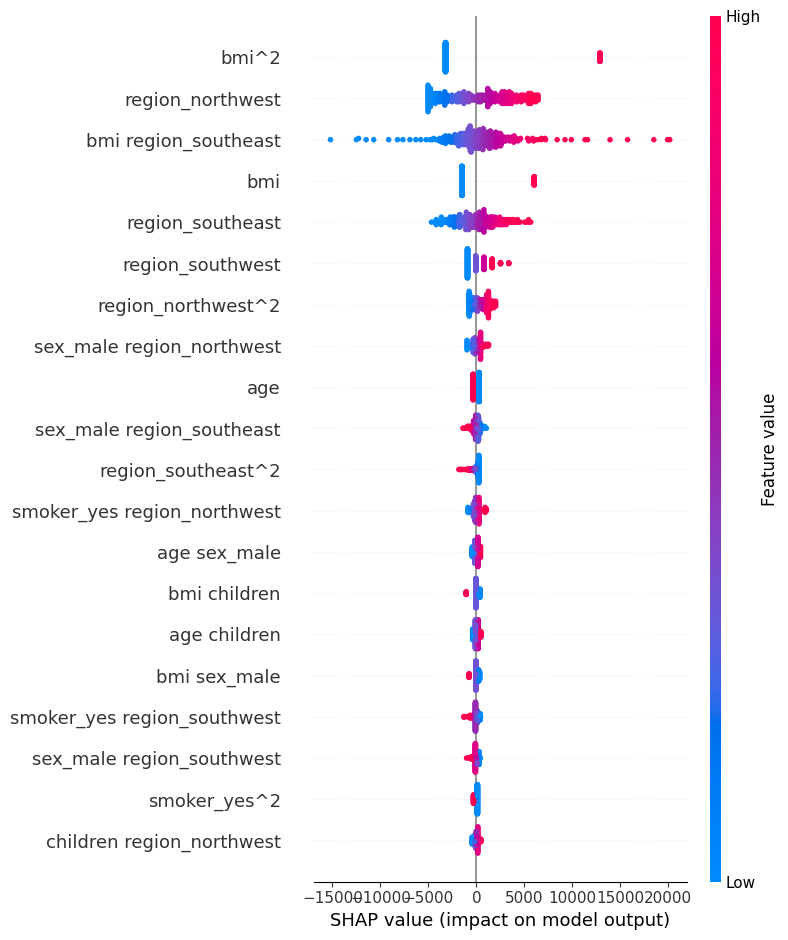

In [112]:
shap.summary_plot(
    shap_values.values,
    X_test_poly,
    feature_names=feature_names,
    max_display=20
)


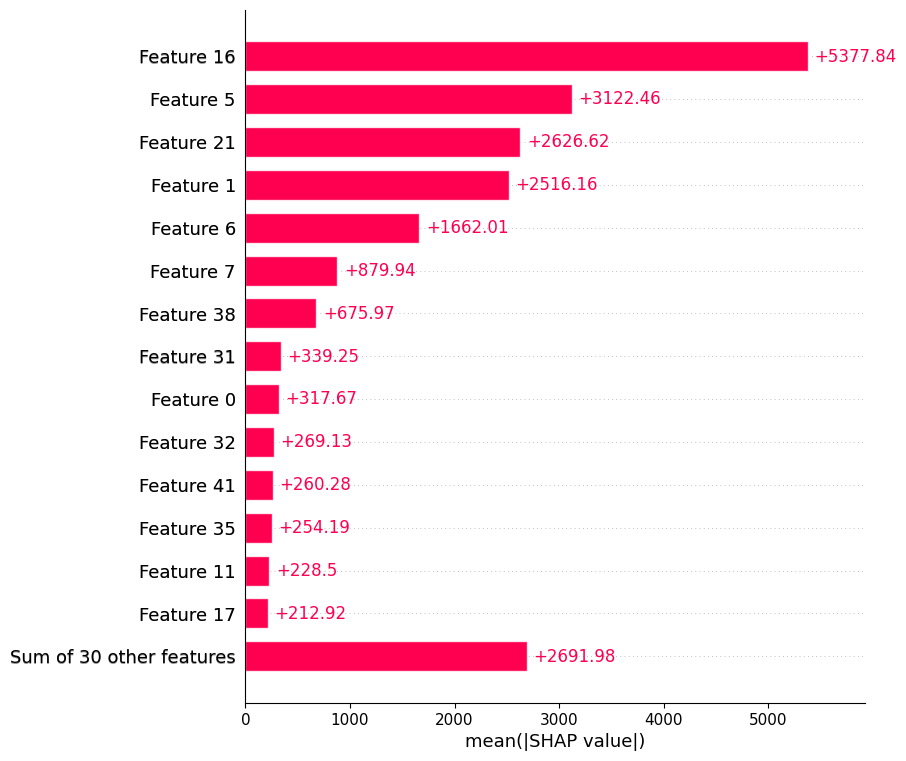

In [113]:
shap.plots.bar(
    shap_values,
    max_display=15
)


Lime

In [114]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)


In [115]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [116]:
original_feature_names = [
    'age',
    'bmi',
    'children',
    'sex_male',
    'smoker_yes',
    'region_northwest',
    'region_southeast',
    'region_southwest'
]


In [117]:
feature_names = poly.get_feature_names_out(original_feature_names)


In [118]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_poly, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [119]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train_poly,
    feature_names=feature_names,
    mode="regression"
)


In [120]:
i = 0
exp = explainer.explain_instance(
    X_test_poly[i],
    model.predict,
    num_features=10
)

print(exp.as_list())


[('bmi^2 <= 0.26', -17232.946496354154), ('bmi region_southeast > 0.40', 7080.521424739563), ('bmi <= -0.51', -5976.103521296905), ('region_southeast <= -0.74', -3615.2816882993056), ('-0.02 < region_northwest <= 0.84', 1811.3576197777243), ('sex_male region_southeast > 0.69', -812.069493044082), ('region_southwest <= -0.91', -744.0596950035422), ('region_southeast^2 > 1.32', -687.2211305473072), ('smoker_yes^2 <= 0.32', 580.0016567254297), ('age sex_male <= -0.61', -562.38461226152)]


Actual vs Predicted (Train vs Test)

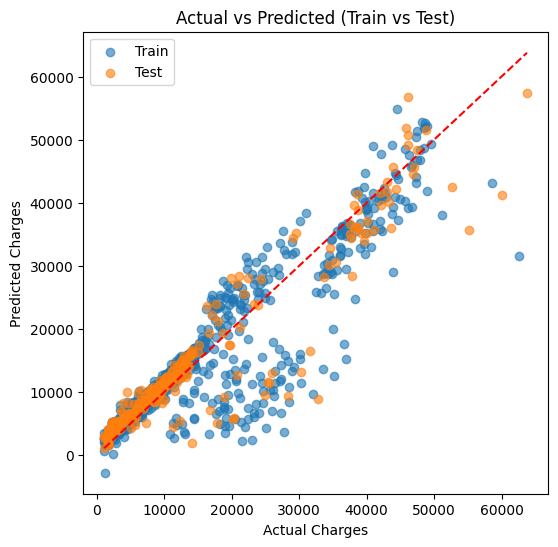

In [121]:

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


model = LinearRegression()

# Train the model
model.fit(X_train_poly, y_train)

# Predictions
train_pred = model.predict(X_train_poly)
test_pred = model.predict(X_test_poly)

plt.figure(figsize=(6,6))
plt.scatter(y_train, train_pred, alpha=0.6, label="Train")
plt.scatter(y_test, test_pred, alpha=0.6, label="Test")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted (Train vs Test)")
plt.legend()
plt.show()


Underfitting Vs Overfitting

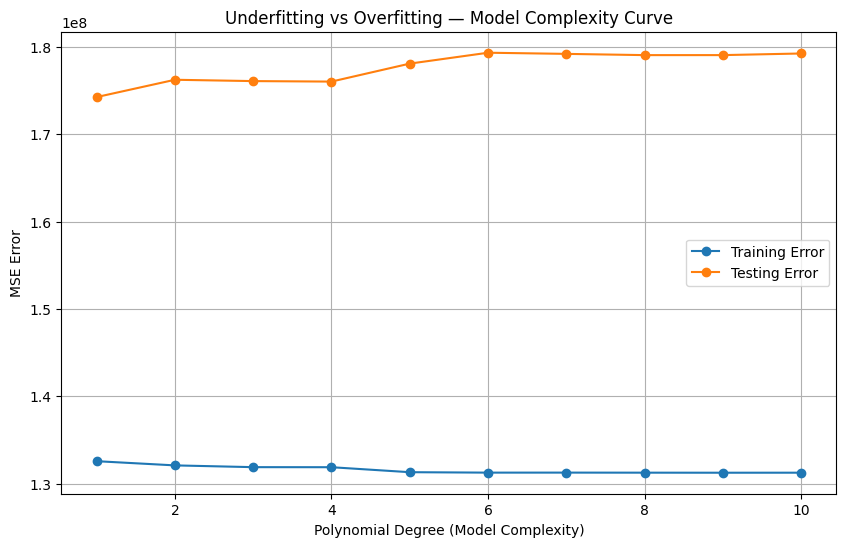

In [122]:

X = df[['bmi']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_errors = []
test_errors = []
degrees = range(1, 11)

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # MSE
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, marker='o', label="Training Error")
plt.plot(degrees, test_errors, marker='o', label="Testing Error")
plt.xlabel("Polynomial Degree (Model Complexity)")
plt.ylabel("MSE Error")
plt.title("Underfitting vs Overfitting — Model Complexity Curve")
plt.legend()
plt.grid(True)
plt.show()


Regression Line (BMI vs Charges)

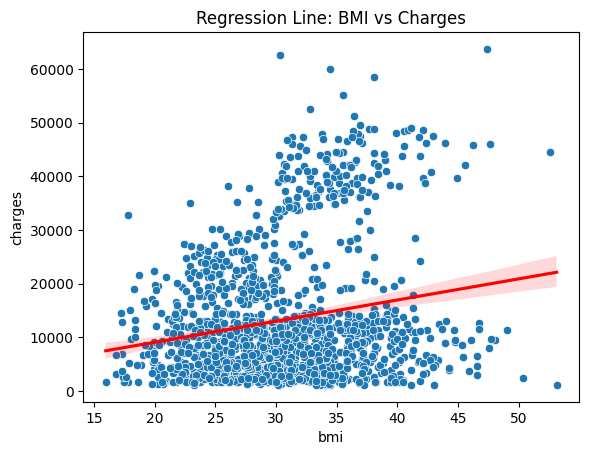

In [123]:
sns.scatterplot(x=df['bmi'], y=df['charges'])
sns.regplot(x=df['bmi'], y=df['charges'], scatter=False, color='red')
plt.title("Regression Line: BMI vs Charges")
plt.show()

Predict charges for a person

In [124]:
test_person = pd.DataFrame({
    'age':[40],
    'sex':['male'],
    'bmi':[30],
    'children':[2],
    'smoker':['no'],
    'region':['southwest']
})

test_processed = preprocessor.transform(test_person)
test_scaled = scaler.transform(test_processed)
prediction = lr.predict(test_scaled)

print("\nPREDICTED CHARGES:", prediction[0])


PREDICTED CHARGES: 8702.15791366688
